In [1]:
import os
os.makedirs('outputs', exist_ok=True)
print("Outputs folder ready!")

Outputs folder ready!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2

# Connect using psycopg2 directly (handles special characters better)
conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="hr analytics_db",
    user="postgres",
    password="Harshit@123"
)

# Load data
df = pd.read_sql('SELECT * FROM hr_employee', conn)
print(df.shape)
df.head()

(1470, 35)


C:\Users\HP\AppData\Local\Temp\ipykernel_28736\1160103479.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql('SELECT * FROM hr_employee', conn)


,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,...,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nAttrition Distribution:\n", df['attrition'].value_counts(normalize=True).round(4) * 100)

Dataset Shape: (1470, 35)

Column Types:
 age                            int64
attrition                     object
business_travel               object
daily_rate                     int64
department                    object
distance_from_home             int64
education                      int64
education_field               object
employee_count                 int64
employee_number                int64
environment_satisfaction       int64
gender                        object
hourly_rate                    int64
job_involvement                int64
job_level                      int64
job_role                      object
job_satisfaction               int64
marital_status                object
monthly_income                 int64
monthly_rate                   int64
num_companies_worked           int64
over_18                       object
over_time                     object
percent_salary_hike            int64
performance_rating             int64
relationship_satisfaction      in

In [7]:
df['attrition_binary'] = (df['attrition'] == 'Yes').astype(int)
df['over_time_binary'] = (df['over_time'] == 'Yes').astype(int)
print("Attrition rate:", df['attrition_binary'].mean().round(4) * 100, "%")

Attrition rate: 16.12 %


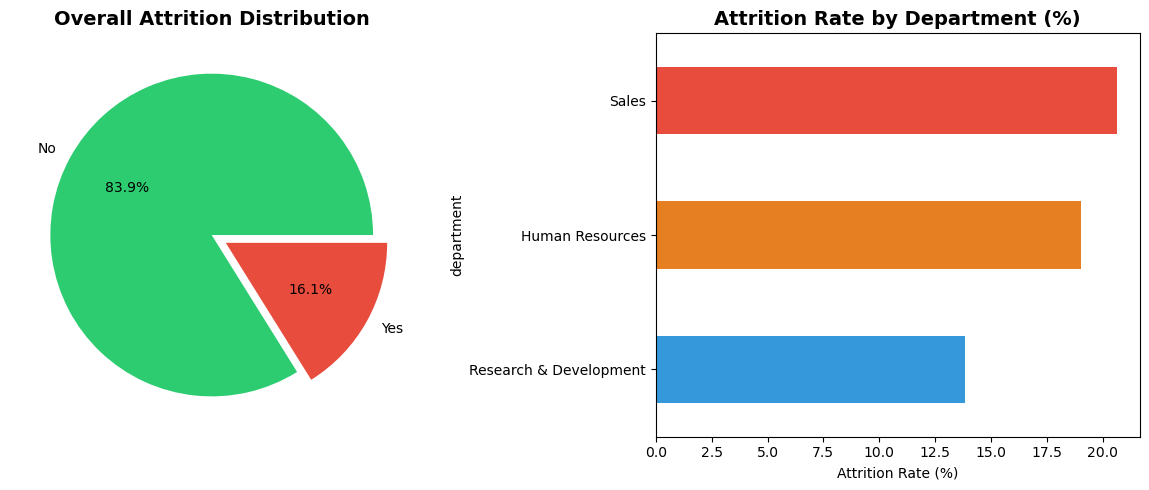

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
df['attrition'].value_counts().plot(
    kind='pie', 
    ax=axes[0], 
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    explode=(0, 0.1)
)
axes[0].set_title('Overall Attrition Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Bar chart by department
dept_attrition = df.groupby('department')['attrition_binary'].mean() * 100
dept_attrition.sort_values(ascending=True).plot(
    kind='barh',
    ax=axes[1],
    color=['#3498db', '#e67e22', '#e74c3c']
)
axes[1].set_title('Attrition Rate by Department (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('outputs/attrition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

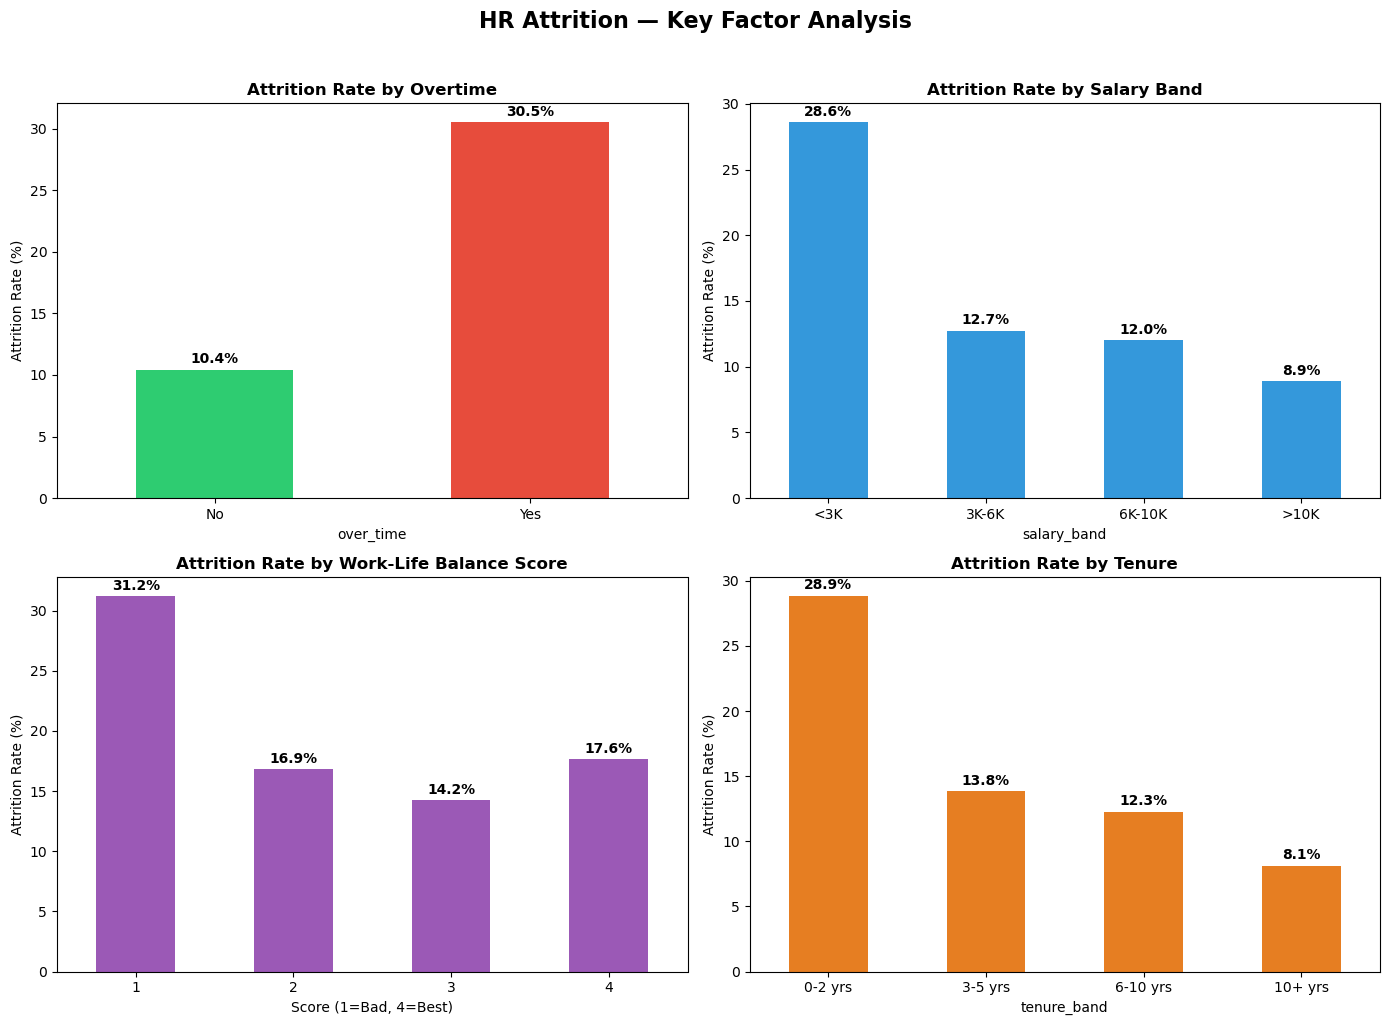

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overtime
overtime_attr = df.groupby('over_time')['attrition_binary'].mean() * 100
overtime_attr.plot(kind='bar', ax=axes[0,0], color=['#2ecc71', '#e74c3c'], rot=0)
axes[0,0].set_title('Attrition Rate by Overtime', fontweight='bold')
axes[0,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(overtime_attr):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Salary band
df['salary_band'] = pd.cut(df['monthly_income'], 
    bins=[0, 3000, 6000, 10000, float('inf')],
    labels=['<3K', '3K-6K', '6K-10K', '>10K'])
salary_attr = df.groupby('salary_band', observed=True)['attrition_binary'].mean() * 100
salary_attr.plot(kind='bar', ax=axes[0,1], color='#3498db', rot=0)
axes[0,1].set_title('Attrition Rate by Salary Band', fontweight='bold')
axes[0,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(salary_attr):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Work life balance
wlb_attr = df.groupby('work_life_balance')['attrition_binary'].mean() * 100
wlb_attr.plot(kind='bar', ax=axes[1,0], color='#9b59b6', rot=0)
axes[1,0].set_title('Attrition Rate by Work-Life Balance Score', fontweight='bold')
axes[1,0].set_ylabel('Attrition Rate (%)')
axes[1,0].set_xlabel('Score (1=Bad, 4=Best)')
for i, v in enumerate(wlb_attr):
    axes[1,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Tenure
df['tenure_band'] = pd.cut(df['years_at_company'],
    bins=[0, 2, 5, 10, float('inf')],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '10+ yrs'])
tenure_attr = df.groupby('tenure_band', observed=True)['attrition_binary'].mean() * 100
tenure_attr.plot(kind='bar', ax=axes[1,1], color='#e67e22', rot=0)
axes[1,1].set_title('Attrition Rate by Tenure', fontweight='bold')
axes[1,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(tenure_attr):
    axes[1,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('HR Attrition — Key Factor Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/key_factors.png', dpi=150, bbox_inches='tight')
plt.show()

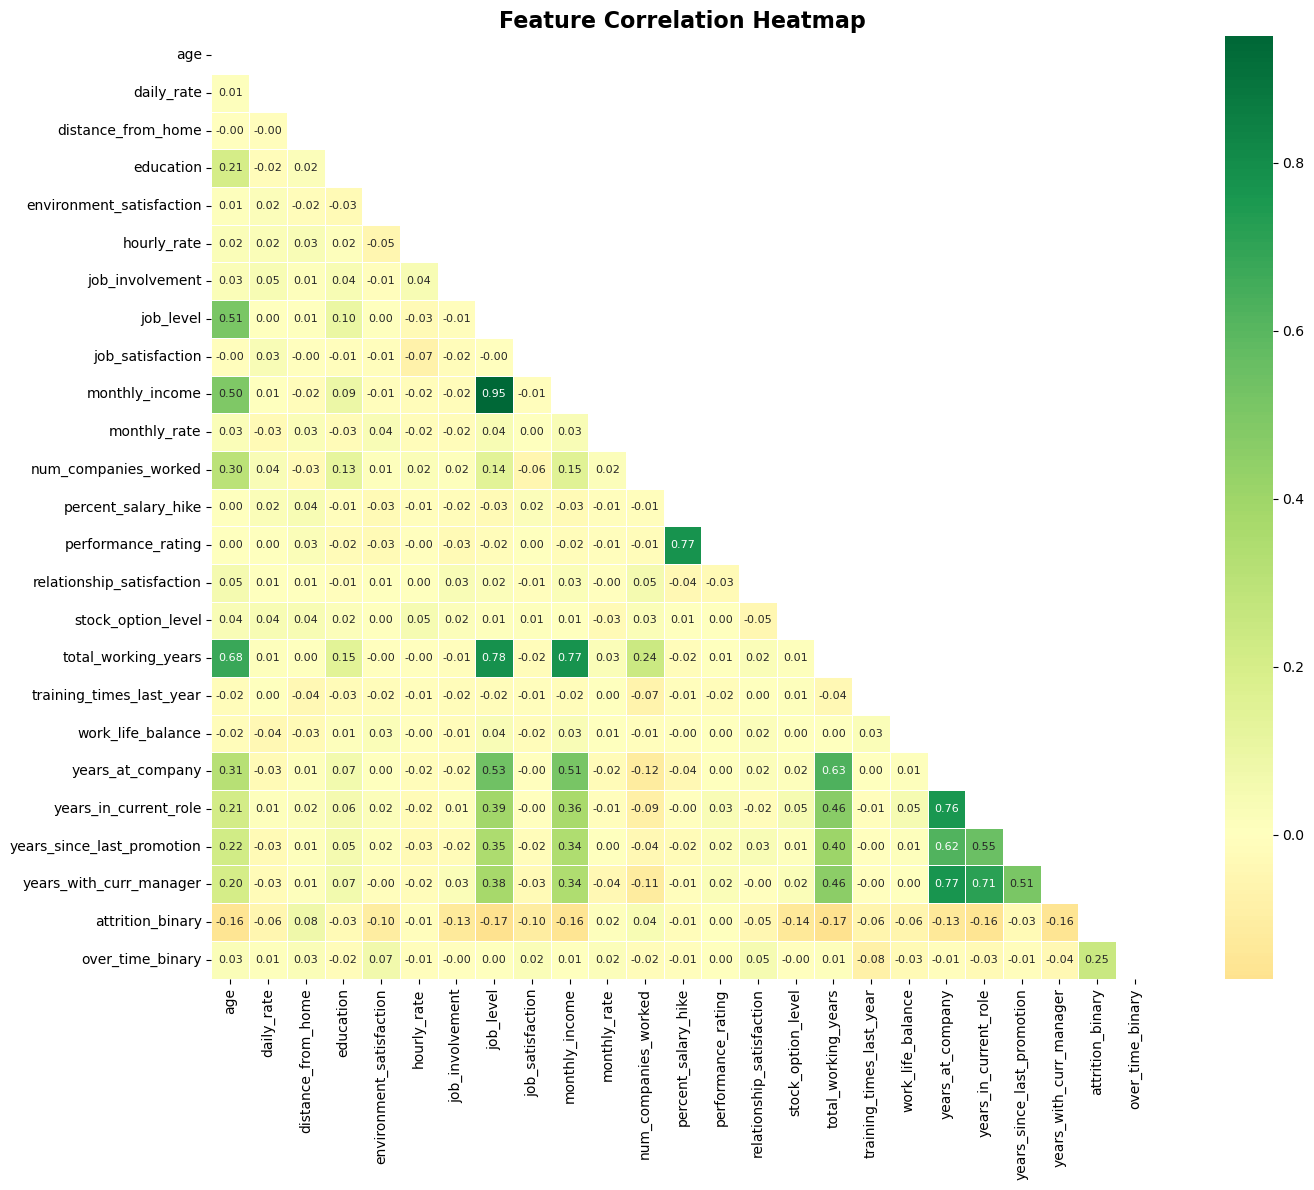

In [10]:
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['employee_count', 'employee_number', 'standard_hours']]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare features
df_model = df.copy()

# Encode categorical columns
cat_cols = ['business_travel', 'department', 'education_field', 
            'gender', 'job_role', 'marital_status', 'over_time']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Drop unnecessary columns
drop_cols = ['attrition', 'over_18', 'employee_count', 'employee_number', 
             'standard_hours', 'attrition_binary', 'salary_band', 'tenure_band']
feature_cols = [c for c in df_model.columns if c not in drop_cols]

X = df_model[feature_cols]
y = df_model['attrition_binary']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 84.01 %

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294



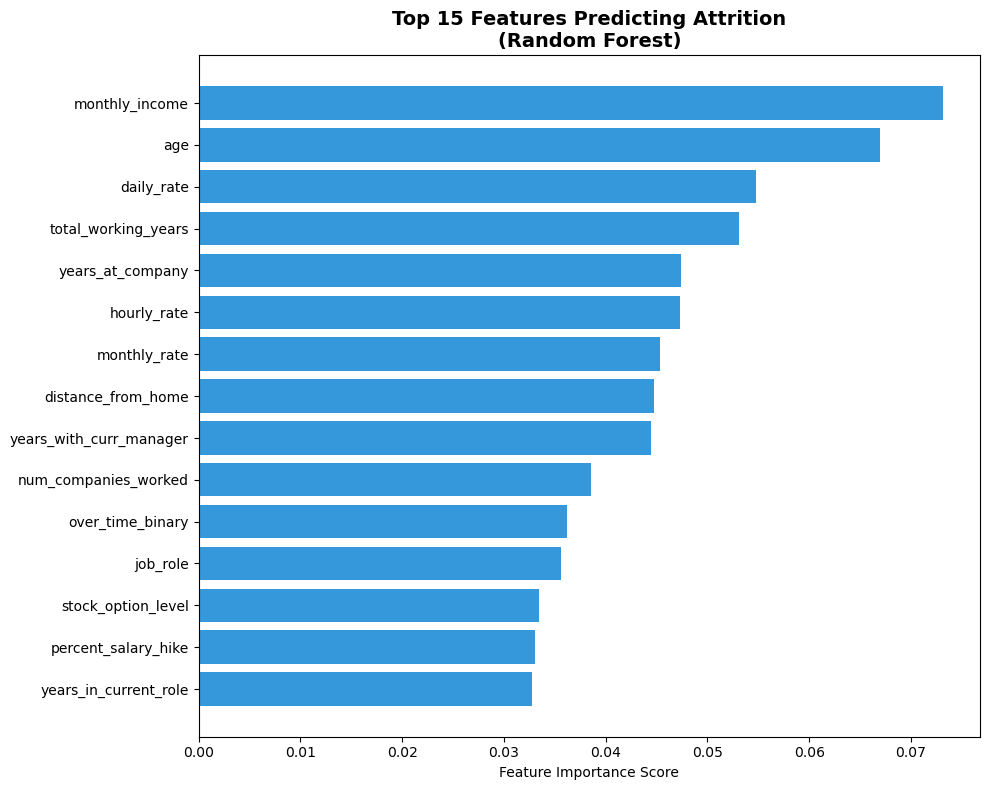

In [12]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='#3498db')
plt.title('Top 15 Features Predicting Attrition\n(Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()